# 1. Configuration and Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.splitting import get_source_name

# 2. Load & Prepare Data
Loading the error report from the latest trained version.

In [2]:
# Get info about latest saved version
with open("../latest_version.txt") as f:
    VERSION = f.read().strip()

BASE_DIR = Path(f"../reports/{VERSION}")

df_err = pd.read_csv(BASE_DIR / "classification_errors.csv")

# 3. Error Aggregation by Source File
Identifying which original files generate the most errors.

In [3]:
# Create new column
df_err["source_file"] = df_err["file_path"].apply(get_source_name)

# Aggregation: count number of errors
err_report = (
    df_err.groupby("source_file")
    .agg(
        err_nb=("source_file", "count"),
        true_label=("true_label", "first"),
        predicted_label=("predicted_label", lambda x: ", ".join(x.unique())),
    )
    .sort_values(by="err_nb", ascending=False)
)

# Write to csv
err_report.to_csv(BASE_DIR / "error_source_report.csv", index=True)

# Display
display(err_report.head(10))

,err_nb,true_label,predicted_label
source_file,,,
yell_test.wav,258,Violence,"Ambient, Speech"
argument2_dospr.mp3,102,Violence,"Ambient, Speech"
dishwasher.wav,81,Ambient,"Speech, Violence"
yell2.wav,72,Violence,Speech
talk_russian.wav,31,Speech,Ambient
yell4.wav,16,Violence,Speech
noise2.wav,12,Ambient,Speech
angry_201.wav,11,Violence,"Speech, Ambient"
yell&argument2.wav,9,Violence,Speech


# 4. Visualization
Visualizing the top 10 problematic recordings.

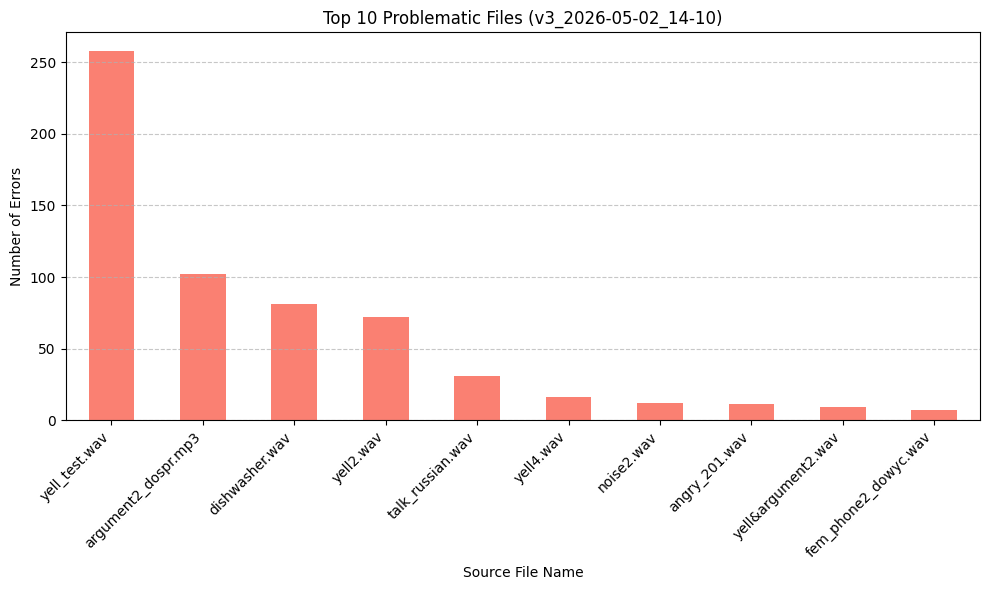

In [4]:
plt.figure(figsize=(10, 6))
err_report["err_nb"].head(10).plot(kind="bar", color="salmon")

plt.title(f"Top 10 Problematic Files ({VERSION})")
plt.ylabel("Number of Errors")
plt.xlabel("Source File Name")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Save chart
plt.tight_layout()  # Ensures all labels are fully visible and not clipped
plt.savefig(BASE_DIR / "top_errors_chart.png")

plt.show()